In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')
print('All libraries imported!')

All libraries imported!


In [3]:
#load RFM data
rfm=pd.read_csv('cognicart/data/cleaned/rfm_table.csv')
print('RFM data loaded')
print(f'shape:{rfm.shape}')
print(rfm.head(10))
print()
print('Basic Statistics:')
print(rfm.describe().round(2))

RFM data loaded
shape:(500, 4)
  Customer_ID  Recency  Frequency  Monetory
0       C0001       53         60  40618.90
1       C0002       20         77  57756.39
2       C0003       39         36  29417.80
3       C0004       27         48  43045.55
4       C0005       51         80  59779.96
5       C0006        4         46  28680.38
6       C0007       16         63  45555.28
7       C0008       52         24  15738.42
8       C0009       18         60  42024.04
9       C0010      108         30  21554.74

Basic Statistics:
       Recency  Frequency  Monetory
count   500.00     500.00    500.00
mean     36.78      55.19  42310.51
std      36.91      17.70  14240.96
min       0.00       8.00   3311.21
25%      11.00      43.00  32130.48
50%      25.00      55.00  42191.55
75%      47.00      67.00  51837.01
max     245.00     117.00  88715.19


In [5]:
#normalize the data
#select only 3 rfm columns for clustering
rfm_features=rfm[['Recency','Frequency','Monetory']]
#create scaler objects
scaler=StandardScaler()
#normalize data
rfm_scaled=scaler.fit_transform(rfm_features)
#convert back to DataFrame
rfm_scaled_df=pd.DataFrame(rfm_scaled,
                           columns=['Recency','Frequency','Monetory']
                          )
print('Data normalized')
print('Before normalization (first 3 rows):')
print(rfm_features.head(3))
print()
print('After normalization (first 3 rows):')
print(rfm_scaled_df.head(3).round(3))

Data normalized
Before normalization (first 3 rows):
   Recency  Frequency  Monetory
0       53         60  40618.90
1       20         77  57756.39
2       39         36  29417.80

After normalization (first 3 rows):
   Recency  Frequency  Monetory
0    0.440      0.272    -0.119
1   -0.455      1.233     1.086
2    0.060     -1.085    -0.906


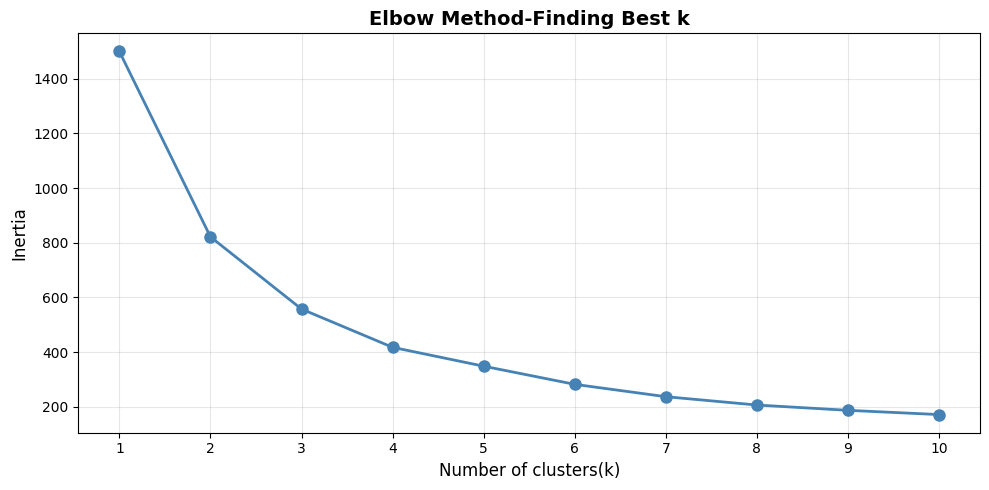

Elbow chart saved!


In [7]:
#elbow method to find best k
#trying from 1 to 10
inertia_values=[]
k_range=range(1,11)
for k in k_range:
    kmeans=KMeans(n_clusters=k,random_state=42,n_init=10)
    kmeans.fit(rfm_scaled_df)
    inertia_values.append(kmeans.inertia_)
#draw elbow chart
plt.figure(figsize=(10,5))
plt.plot(k_range,inertia_values,
        marker='o',
        color='steelblue',
        linewidth=2,
        markersize=8)
plt.xlabel('Number of clusters(k)',fontsize=12)
plt.ylabel('Inertia',fontsize=12)
plt.title('Elbow Method-Finding Best k',fontsize=14,fontweight='bold')
plt.xticks(k_range)
plt.grid(True,alpha=0.3)
plt.tight_layout()
plt.savefig('cognicart/outputs/week4_elbow.png',dpi=150)
plt.show()
print('Elbow chart saved!')

In [9]:
#silhouette score to confirm best k
#it is the second way to confirm best k.higher score=better separated clusters. score ranges from -1 to 1
silhouette_scores=[]
k_range2=range(2,9)
for k in k_range2:
    kmeans=KMeans(n_clusters=k,random_state=42,n_init=10)
    labels=kmeans.fit_predict(rfm_scaled_df)
    score=silhouette_score(rfm_scaled_df,labels)
    silhouette_scores.append(score)
    print(f'K={k}Silhouette Score:{score:.3f}')
#find best k
best_k=list(k_range2)[silhouette_scores.index(max(silhouette_scores))]
print(f'Best K based on silhouette score={best_k}')

K=2Silhouette Score:0.395
K=3Silhouette Score:0.398
K=4Silhouette Score:0.357
K=5Silhouette Score:0.364
K=6Silhouette Score:0.357
K=7Silhouette Score:0.370
K=8Silhouette Score:0.339
Best K based on silhouette score=3


In [11]:
#train final k-means model
#set k based on elbow and silhouette results
BEST_K=4
#tain final model
kmeans_final=KMeans(n_clusters=BEST_K,random_state=42,n_init=10)
rfm['Cluster']=kmeans_final.fit_predict(rfm_scaled_df)
print(f'K-Means trained with K={BEST_K}')
print()
print('Number of customers per clusters:')
print(rfm['Cluster'].value_counts().sort_index())
print()
print('Sample Output:')
print(rfm.head(10))

K-Means trained with K=4

Number of customers per clusters:
Cluster
0    213
1    112
2     63
3    112
Name: count, dtype: int64

Sample Output:
  Customer_ID  Recency  Frequency  Monetory  Cluster
0       C0001       53         60  40618.90        0
1       C0002       20         77  57756.39        3
2       C0003       39         36  29417.80        1
3       C0004       27         48  43045.55        0
4       C0005       51         80  59779.96        3
5       C0006        4         46  28680.38        1
6       C0007       16         63  45555.28        0
7       C0008       52         24  15738.42        1
8       C0009       18         60  42024.04        0
9       C0010      108         30  21554.74        2


In [13]:
#analyze each customer
cluster_summary=rfm.groupby('Cluster').agg(
    Num_Customers=('Customer_ID','count'),
    Avg_Recency=('Recency','mean'),
    Avg_Frequency=('Frequency','mean'),
    Avg_Monetory=('Monetory','mean')
     ).round(2)

print('Cluster Summary:')
print(cluster_summary)
print()
#lael cluster based on rfm
cluster_labels={
    0:'Premium Shoppers',
    1:'Regular Shoppers',
    2:'Budget Shoppers',
    3:'Bulk Buyers'
}
rfm['Segment']=rfm['Cluster'].map(cluster_labels)
print('Customers with Segment Labels:')
print(rfm.head(10))
    

Cluster Summary:
         Num_Customers  Avg_Recency  Avg_Frequency  Avg_Monetory
Cluster                                                         
0                  213        28.04          57.39      44179.69
1                  112        27.71          36.98      27733.35
2                   63       113.62          37.95      28223.06
3                  112        19.25          78.91      61257.08

Customers with Segment Labels:
  Customer_ID  Recency  Frequency  Monetory  Cluster           Segment
0       C0001       53         60  40618.90        0  Premium Shoppers
1       C0002       20         77  57756.39        3       Bulk Buyers
2       C0003       39         36  29417.80        1  Regular Shoppers
3       C0004       27         48  43045.55        0  Premium Shoppers
4       C0005       51         80  59779.96        3       Bulk Buyers
5       C0006        4         46  28680.38        1  Regular Shoppers
6       C0007       16         63  45555.28        0  Premium Sh

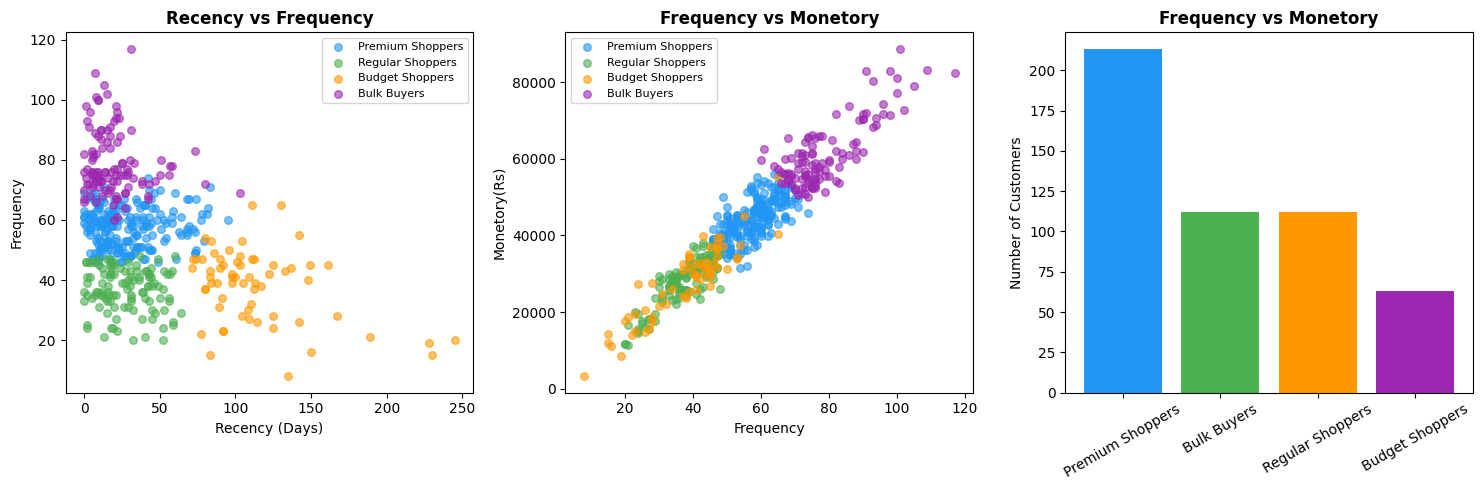

Cluster charts saved!


In [15]:
#visualize clusters
fig,axes=plt.subplots(1,3,figsize=(15,5))
colors=['#2196F3','#4CAF50','#FF9800','#9C27B0']
#chart1:Recency and frequency
for cluster in range(BEST_K):
    data=rfm[rfm['Cluster']==cluster]
    axes[0].scatter(data['Recency'],data['Frequency'],
    c=colors[cluster],label=cluster_labels[cluster],
    alpha=0.6,s=30)
axes[0].set_xlabel('Recency (Days)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Recency vs Frequency',fontweight='bold')
axes[0].legend(fontsize=8)
#chart 2:Frequency vs Monetory
for cluster in range(BEST_K):
    data=rfm[rfm['Cluster']==cluster]
    axes[1].scatter(data['Frequency'],data['Monetory'],
    c=colors[cluster],label=cluster_labels[cluster],
    alpha=0.6,s=30)
axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('Monetory(Rs)')
axes[1].set_title('Frequency vs Monetory',fontweight='bold')
axes[1].legend(fontsize=8)
#chart 3:customer count per segment
segment_counts=rfm['Segment'].value_counts()
axes[2].bar(segment_counts.index,segment_counts.values,
            color=colors[:len(segment_counts)])
axes[2].set_ylabel('Number of Customers')
axes[2].set_title('Frequency vs Monetory',fontweight='bold')
axes[2].tick_params(axis='x',rotation=30)
plt.tight_layout()
plt.savefig('cognicart/outputs/week4_clusters.png',dpi=150)
plt.show()
print('Cluster charts saved!')


In [19]:
#segment wise MBA rule
#most powerful part we will FP-growth separately for each customer segment.this gives specific rules for each type of customer
from mlxtend.frequent_patterns import fpgrowth,association_rules
from mlxtend.preprocessing import TransactionEncoder
#load clean transaction data
df_clean=pd.read_csv('cognicart/data/cleaned/supermarket_clean.csv')
#merge cluster labels into transaction data
df_merged=df_clean.merge(
    rfm[['Customer_ID','Segment']],
    on='Customer_ID',
    how='left'
)
print("Data merged with segments")
print(df_merged[['Customer_ID','Product','Segment']].head(10))
print()
print('Transaction per segment')
print(df_merged.groupby('Segment')['TransactionID'].nunique())

Data merged with segments
  Customer_ID      Product           Segment
0       C0027       Panner  Regular Shoppers
1       C0027       Cheese  Regular Shoppers
2       C0027        Bread  Regular Shoppers
3       C0027          Tea  Regular Shoppers
4       C0027   Cold Drink  Regular Shoppers
5       C0027        Chips  Regular Shoppers
6       C0027     Biscuits  Regular Shoppers
7       C0027       Banana  Regular Shoppers
8       C0108  Tomatosauce  Premium Shoppers
9       C0108          Tea  Premium Shoppers

Transaction per segment
Segment
Budget Shoppers      2391
Bulk Buyers          8838
Premium Shoppers    12225
Regular Shoppers     4142
Name: TransactionID, dtype: int64


In [31]:
#run MBA per segment
#dictionary to store rules for each segment
segment_rules={}
#get unique segments name
segments=df_merged['Segment'].dropna().unique()
for segment in segments:
    print(f'Processing Segment:{segment}')
    #filter transaction for this segment only
    seg_data=df_merged[df_merged['Segment']==segment]
    #create basket format
    # basket=seg_data.groupby('TransactionID')['Product'].apply(list)
    basket = seg_data.groupby(['Customer_ID', 'Date'])['Product'].apply(list)
    basket = basket[basket.apply(len) >= 2]
    #encode as one hot format
    te=TransactionEncoder()
    te_array=te.fit_transform(basket)
    basket_df=pd.DataFrame(te_array,columns=te.columns_)
    #run fp-growth
    frequent_items=fpgrowth(basket_df,min_support=0.02,use_colnames=True)
    if len(frequent_items)>0:
        rules=association_rules(frequent_items,
                                metric='lift',
                                min_threshold=1.0)
        rules['Segment']=segment
        segment_rules[segment]=rules
        print(f' Found{len(rules)}rules')
    else:
        print(f'No rules found-try lowering min_support')
print()
print('Segment wise MBA complete!')

Processing Segment:Regular Shoppers
 Found958rules
Processing Segment:Premium Shoppers
 Found1198rules
Processing Segment:Bulk Buyers
 Found1250rules
Processing Segment:Budget Shoppers
 Found1076rules

Segment wise MBA complete!


In [35]:
#show top rules for each segment
for segment,rules in segment_rules.items():
    print(f'TOP RULES FOR:{segment}')
    print('='*50)
    #sort by lift and show top 5
    top_rules=rules.sort_values('lift',ascending=False).head(5)
    for _, row in top_rules.iterrows():
     antecedent=','.join(list(row['antecedents']))
     consequent=','.join(list(row['consequents']))
     print(f'IF{antecedent}')
     print(f'THEN{consequent}')
     print(f'Confidence:{row['confidence']:2f} Lift:{row['lift']:2f}')
     print()
    print()


TOP RULES FOR:Regular Shoppers
IFChocolate,Popcorn
THENCold Drink,Namkeen
Confidence:0.566667 Lift:10.586992

IFCold Drink,Namkeen
THENChocolate,Popcorn
Confidence:0.414634 Lift:10.586992

IFChocolate,Popcorn
THENChips,Namkeen
Confidence:0.600000 Lift:10.445455

IFChips,Namkeen
THENChocolate,Popcorn
Confidence:0.409091 Lift:10.445455

IFChocolate,Chips
THENPopcorn,Namkeen
Confidence:0.486486 Lift:10.071585


TOP RULES FOR:Premium Shoppers
IFCold Drink,Biscuits
THENTea,Chips,Bread
Confidence:0.432000 Lift:9.130154

IFTea,Chips,Bread
THENCold Drink,Biscuits
Confidence:0.519231 Lift:9.130154

IFChocolate,Cold Drink
THENChips,Popcorn
Confidence:0.522523 Lift:9.115115

IFChips,Popcorn
THENChocolate,Cold Drink
Confidence:0.460317 Lift:9.115115

IFChocolate,Cold Drink
THENChips,Namkeen
Confidence:0.531532 Lift:9.056638


TOP RULES FOR:Bulk Buyers
IFChocolate,Namkeen
THENChips,Popcorn
Confidence:0.600000 Lift:11.007143

IFChips,Popcorn
THENChocolate,Namkeen
Confidence:0.500000 Lift:11.007143



In [37]:
#save RFM wuth segments
rfm.to_csv('cognicart/data/cleaned/rfm_with_segments.csv',index=False)
#combine all segment rules into one file
all_rules=[]
for segment,rules in segment_rules.items():
    all_rules.append(rules)
if all_rules:
    combined_rules=pd.concat(all_rules,ignore_index=True)
    combined_rules['antecedents']=combined_rules['antecedents'].astype(str)
    combined_rules['consequents']=combined_rules['consequents'].astype(str)
    combined_rules.to_csv('cognicart/data/cleaned/segment_rules.csv',index=False)
    print(f'Total rules saved:{len(combined_rules)}')
print('all result saved')

Total rules saved:4482
all result saved


In [39]:
print('=' * 50)
print('WEEK 4 COMPLETE!')
print('=' * 50)
print()
print('What you built this week:')
print('  Normalized RFM data using StandardScaler')
print('  Found best K using Elbow Method')
print('  Confirmed K using Silhouette Score')
print('  Trained K-Means model')
print('  Analysed and labelled each cluster')
print('  Ran MBA separately for each segment')
print()
print('Customer Segments Created:')
for segment in rfm['Segment'].unique():
    count = len(rfm[rfm['Segment'] == segment])
    print(f'  {segment}: {count} customers')
print()
print('Files saved:')
print('  cognicart/data/cleaned/rfm_with_segments.csv')
print('  cognicart/data/cleaned/segment_rules.csv')
print('  cognicart/outputs/week4_elbow.png')
print('  cognicart/outputs/week4_clusters.png')
print()
print('Next Week: LSTM Deep Learning!')


WEEK 4 COMPLETE!

What you built this week:
  Normalized RFM data using StandardScaler
  Found best K using Elbow Method
  Confirmed K using Silhouette Score
  Trained K-Means model
  Analysed and labelled each cluster
  Ran MBA separately for each segment

Customer Segments Created:
  Premium Shoppers: 213 customers
  Bulk Buyers: 112 customers
  Regular Shoppers: 112 customers
  Budget Shoppers: 63 customers

Files saved:
  cognicart/data/cleaned/rfm_with_segments.csv
  cognicart/data/cleaned/segment_rules.csv
  cognicart/outputs/week4_elbow.png
  cognicart/outputs/week4_clusters.png

Next Week: LSTM Deep Learning!
